# Notebook 03 — Long-range social pressure, uncorrelated duplex

**Goal:** Study the effect of vigilance range L ∈ {1, 2, 3, 4} when the game layer and the
vigilance layer are **independent realizations** of the same random network model
(uncorrelated duplex). Comparison with notebook 02 isolates the role of inter-layer correlation.

Networks: BA and ER, z = 4 and z = 16.  
Update rule: Fermi (K = 0.1).  
Parameters: b ∈ [1.0, 2.0], θ ∈ [0.0, 1.0], N = 1000, 100 replications.

**Structure:**
- **Part I — Simulation:** runs sweeps, saves to `data/03-*.csv`. Run once.
- **Part II — Figures:** loads CSVs, makes all plots independently.
  Includes comparison figures against notebook 02 (correlated).

In [1]:
# ── Shared: imports and parameters ──────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import model

N        = 1000
n_rep    = 100
L_VALUES = [1, 2, 3, 4]
lam      = 0.5
K_fermi  = 0.1
b_vals   = np.round(np.linspace(1.0, 2.0, 11), 2)
th_vals  = np.round(np.linspace(0.0, 1.0, 11), 2)
NET_SEED     = 0      # seed for game layer network
NET_VIG_SEED = 100    # different seed → independent vigilance layer network
SIM_SEED     = 0
N_JOBS       = -1

NETWORKS = [
    ('BA_z4',  'BA', 4,  r'BA, $z=4$'),
    ('BA_z16', 'BA', 16, r'BA, $z=16$'),
    ('ER_z4',  'ER', 4,  r'ER, $z=4$'),
    ('ER_z16', 'ER', 16, r'ER, $z=16$'),
]

os.makedirs('data',    exist_ok=True)
os.makedirs('figures', exist_ok=True)
print('b:', b_vals)
print('θ:', th_vals)

b: [1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2. ]
θ: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


---
## Part I — Simulation
*Run once. G_game and G_vig are independent realizations (different random seeds).*

In [2]:
# ── Build network pairs ──────────────────────────────────────────────────────
# G_game: used for payoffs and strategy update.
# G_vig:  used for vigilance influence (independent realization, same parameters).
game_graphs = {
    key: model.build_network(topo, N, z, seed=NET_SEED)
    for key, topo, z, _ in NETWORKS
}
vig_graphs = {
    key: model.build_network(topo, N, z, seed=NET_VIG_SEED)
    for key, topo, z, _ in NETWORKS
}

for key, topo, z, label in NETWORKS:
    Gg = game_graphs[key]
    Gv = vig_graphs[key]
    print(
        f"{label:14s}  "
        f"game: <k>={2*Gg.number_of_edges()/Gg.number_of_nodes():.2f} diam={nx.diameter(Gg)}  "
        f"vig:  <k>={2*Gv.number_of_edges()/Gv.number_of_nodes():.2f} diam={nx.diameter(Gv)}"
    )

BA, $z=4$       game: <k>=3.99 diam=7  vig:  <k>=3.99 diam=8


BA, $z=16$      game: <k>=15.87 diam=4  vig:  <k>=15.87 diam=4


ER, $z=4$       game: <k>=4.11 diam=10  vig:  <k>=3.99 diam=11


ER, $z=16$      game: <k>=16.21 diam=4  vig:  <k>=15.70 diam=4


In [3]:
# ── Pre-compile JIT kernels ─────────────────────────────────────────────────
model.warm_up()
print('JIT kernels compiled.')

JIT kernels compiled.


In [4]:
# ── Run sweeps (uncorrelated: G_vig ≠ G_game) ───────────────────────────────
for key, topo, z, label in NETWORKS:
    Gg     = game_graphs[key]
    Gv     = vig_graphs[key]
    gp, gd = model.game_csr(Gg)   # game layer CSR
    for L in L_VALUES:
        path = f"data/03-{key}-L{L}.csv"
        if os.path.exists(path):
            print(f"  skip: {path}")
            continue
        print(f"  running {label}  L={L} ...", flush=True)
        sp, sd = model.shells_csr(Gv, L)   # vigilance shells from G_vig
        al     = model.geometric_kernel(L, lam)
        df = model.run_sweep(
            gp, gd, sp, sd, al,
            b_vals, th_vals,
            K=K_fermi, n_rep=n_rep,
            n_jobs=N_JOBS, base_seed=SIM_SEED,
            update_rule='fermi',
        )
        df.to_csv(path, index=False)
        print(f"  saved: {path}")

print('Part I done.')

  running BA, $z=4$  L=1 ...


  saved: data/03-BA_z4-L1.csv
  running BA, $z=4$  L=2 ...


  saved: data/03-BA_z4-L2.csv
  running BA, $z=4$  L=3 ...


  saved: data/03-BA_z4-L3.csv
  running BA, $z=4$  L=4 ...


  saved: data/03-BA_z4-L4.csv
  running BA, $z=16$  L=1 ...


...

  saved: data/03-ER_z4-L4.csv
  running ER, $z=16$  L=1 ...


  saved: data/03-ER_z16-L1.csv
  running ER, $z=16$  L=2 ...


  saved: data/03-ER_z16-L2.csv
  running ER, $z=16$  L=3 ...


  saved: data/03-ER_z16-L3.csv
  running ER, $z=16$  L=4 ...


  saved: data/03-ER_z16-L4.csv
Part I done.


---
## Part II — Figures
*Loads CSVs from `data/`. For correlated vs uncorrelated comparison, also loads `data/02-*.csv`.*

In [5]:
# ── Load results ─────────────────────────────────────────────────────────────
data_unc = {}   # uncorrelated (this notebook)
data_cor = {}   # correlated   (notebook 02, for comparison)

for key, topo, z, label in NETWORKS:
    for L in L_VALUES:
        data_unc[(key, L)] = pd.read_csv(f"data/03-{key}-L{L}.csv")
        data_cor[(key, L)] = pd.read_csv(f"data/02-{key}-L{L}.csv")
        print(f"  loaded 03 and 02  {key} L={L}")

  loaded 03 and 02  BA_z4 L=1
  loaded 03 and 02  BA_z4 L=2
  loaded 03 and 02  BA_z4 L=3
  loaded 03 and 02  BA_z4 L=4
  loaded 03 and 02  BA_z16 L=1
  loaded 03 and 02  BA_z16 L=2
  loaded 03 and 02  BA_z16 L=3
  loaded 03 and 02  BA_z16 L=4
  loaded 03 and 02  ER_z4 L=1
  loaded 03 and 02  ER_z4 L=2
  loaded 03 and 02  ER_z4 L=3
  loaded 03 and 02  ER_z4 L=4
  loaded 03 and 02  ER_z16 L=1
  loaded 03 and 02  ER_z16 L=2
  loaded 03 and 02  ER_z16 L=3
  loaded 03 and 02  ER_z16 L=4


In [6]:
# ── Figure settings ──────────────────────────────────────────────────────────
import matplotlib as mpl

plt.rcParams.update({
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 120,
})

CMAP = 'GnBu'
CMAP_DIFF = 'RdBu'  # red=decrease, blue=increase -- standard diverging map
VMIN, VMAX = 0.0, 1.0
VDIFF      = 0.4
THETA_SHOW = [0.3, 0.5, 0.7]

_d2      = mpl.colormaps['Dark2']
DARK2    = {1: _d2(0), 2: _d2(1), 3: _d2(2), 4: _d2(3)}
L_STYLES = {1: '-',   2: '--',   3: '-.',   4: ':'}
LW       = 2.0

db, dt = b_vals[1] - b_vals[0], th_vals[1] - th_vals[0]
EXTENT = [b_vals[0]-db/2, b_vals[-1]+db/2, th_vals[0]-dt/2, th_vals[-1]+dt/2]

def rho_matrix(df):
    return (
        df.pivot(index='theta', columns='b', values='rho_mean')
          .sort_index(ascending=True)
          .values
    )

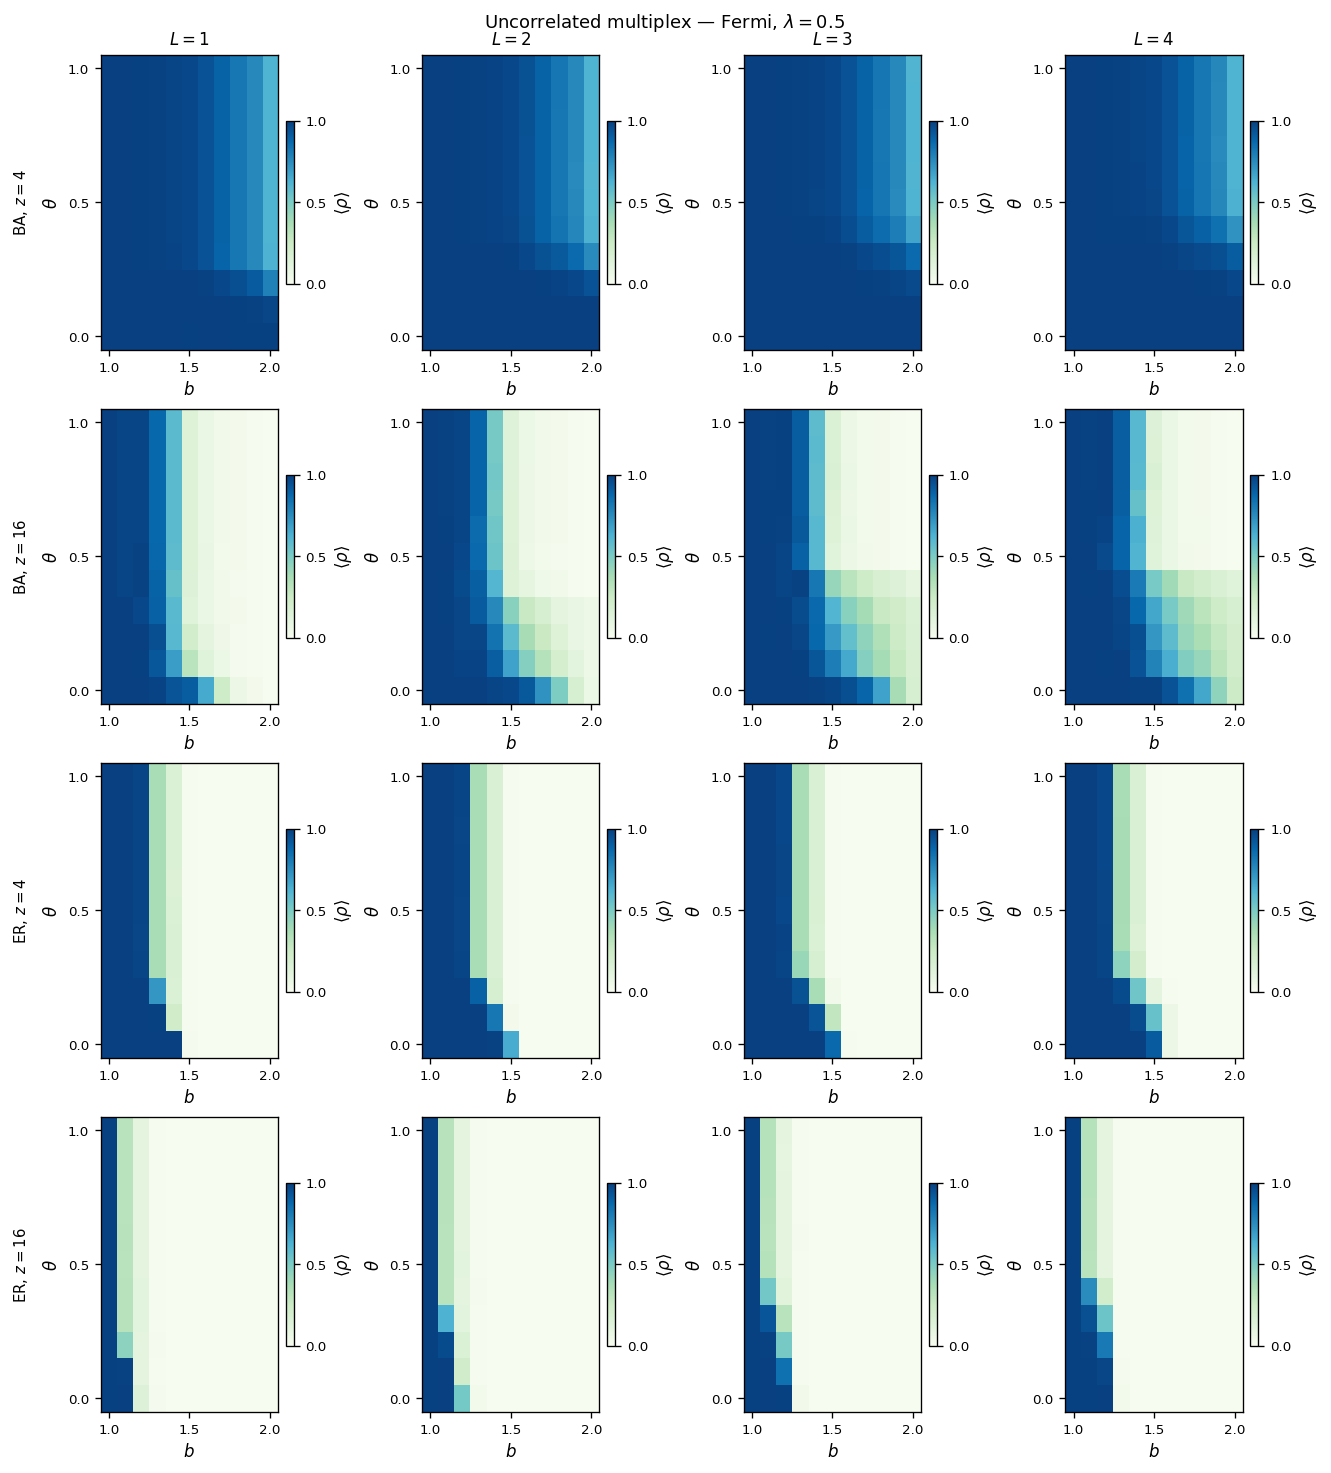

Saved figures/03-heatmaps.pdf


In [7]:
# ── Figure 1: heatmaps — uncorrelated multiplex, rows = networks, cols = L ───
fig1, axes = plt.subplots(
    len(NETWORKS), len(L_VALUES),
    figsize=(11, 12),
    constrained_layout=True,
)

for row, (key, topo, z, label) in enumerate(NETWORKS):
    for col, L in enumerate(L_VALUES):
        ax  = axes[row, col]
        mat = rho_matrix(data_unc[(key, L)])
        im  = ax.imshow(mat, origin='lower', aspect='auto',
                        vmin=VMIN, vmax=VMAX, cmap=CMAP, extent=EXTENT)
        ax.set_xlabel('$b$'); ax.set_ylabel(r'$\theta$')
        ax.xaxis.set_major_locator(mticker.MultipleLocator(0.5))
        ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
        if row == 0: ax.set_title(f'$L={L}$', fontweight='bold')
        if col == 0:
            ax.text(-0.45, 0.5, label, transform=ax.transAxes,
                    rotation=90, va='center', ha='center', fontsize=9)
        cb = fig1.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        cb.set_label(r'$\langle\rho\rangle$'); cb.set_ticks([0, 0.5, 1.0])

fig1.suptitle('Uncorrelated multiplex — Fermi, $\\lambda=0.5$', y=1.01)
fig1.savefig('figures/03-heatmaps.pdf', bbox_inches='tight')
plt.show()
print('Saved figures/03-heatmaps.pdf')

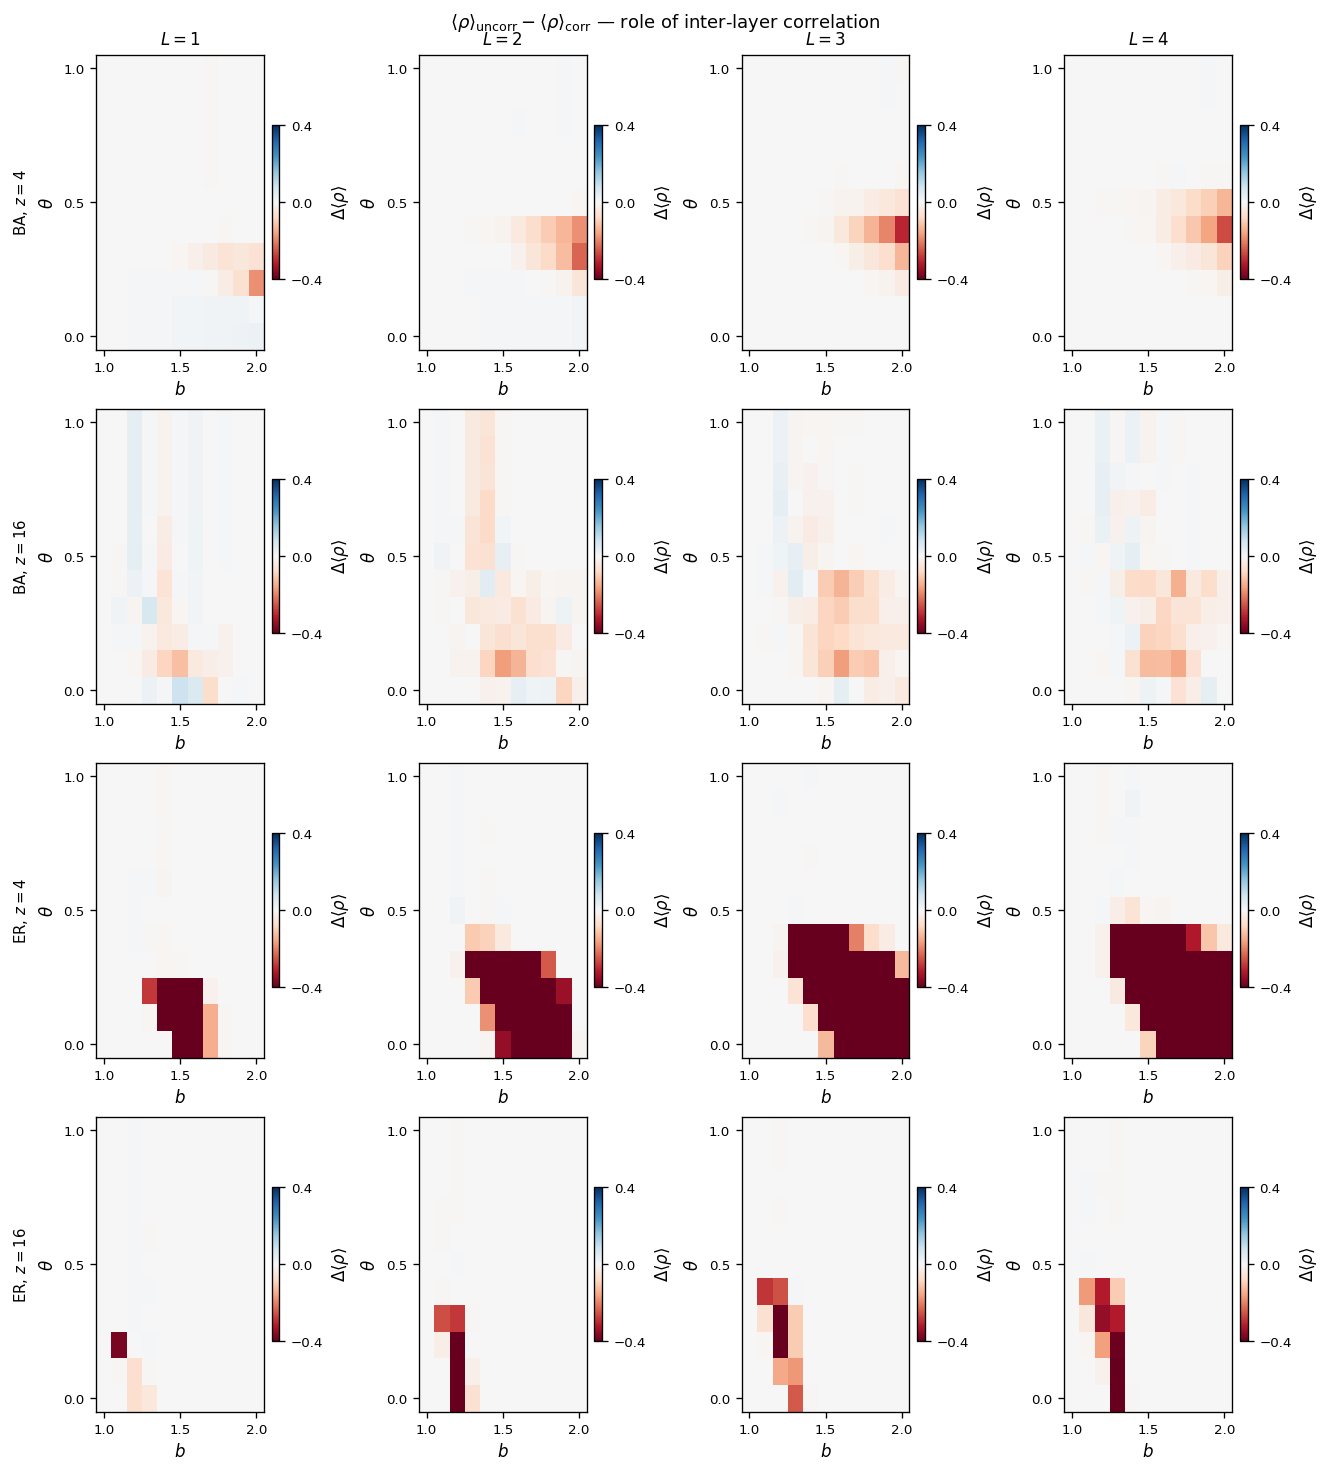

Saved figures/03-corr-vs-uncorr.pdf


In [8]:
# ── Figure 2: correlated vs uncorrelated — difference maps ───────────────────
# Δρ = rho_uncorrelated − rho_correlated.
# Blue = uncorrelated promotes more cooperation; red = correlated is better.
fig2, axes2 = plt.subplots(
    len(NETWORKS), len(L_VALUES),
    figsize=(11, 12),
    constrained_layout=True,
)

for row, (key, topo, z, label) in enumerate(NETWORKS):
    for col, L in enumerate(L_VALUES):
        ax   = axes2[row, col]
        diff = rho_matrix(data_unc[(key, L)]) - rho_matrix(data_cor[(key, L)])
        im   = ax.imshow(diff, origin='lower', aspect='auto',
                         vmin=-VDIFF, vmax=VDIFF, cmap=CMAP_DIFF, extent=EXTENT)
        ax.set_xlabel('$b$'); ax.set_ylabel(r'$\theta$')
        ax.xaxis.set_major_locator(mticker.MultipleLocator(0.5))
        ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
        if row == 0: ax.set_title(f'$L={L}$', fontweight='bold')
        if col == 0:
            ax.text(-0.45, 0.5, label, transform=ax.transAxes,
                    rotation=90, va='center', ha='center', fontsize=9)
        cb = fig2.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        cb.set_label(r'$\Delta\langle\rho\rangle$'); cb.set_ticks([-VDIFF, 0, VDIFF])

fig2.suptitle(
    r'$\langle\rho\rangle_{\rm uncorr} - \langle\rho\rangle_{\rm corr}$'
    ' — role of inter-layer correlation', y=1.01,
)
fig2.savefig('figures/03-corr-vs-uncorr.pdf', bbox_inches='tight')
plt.show()
print('Saved figures/03-corr-vs-uncorr.pdf')

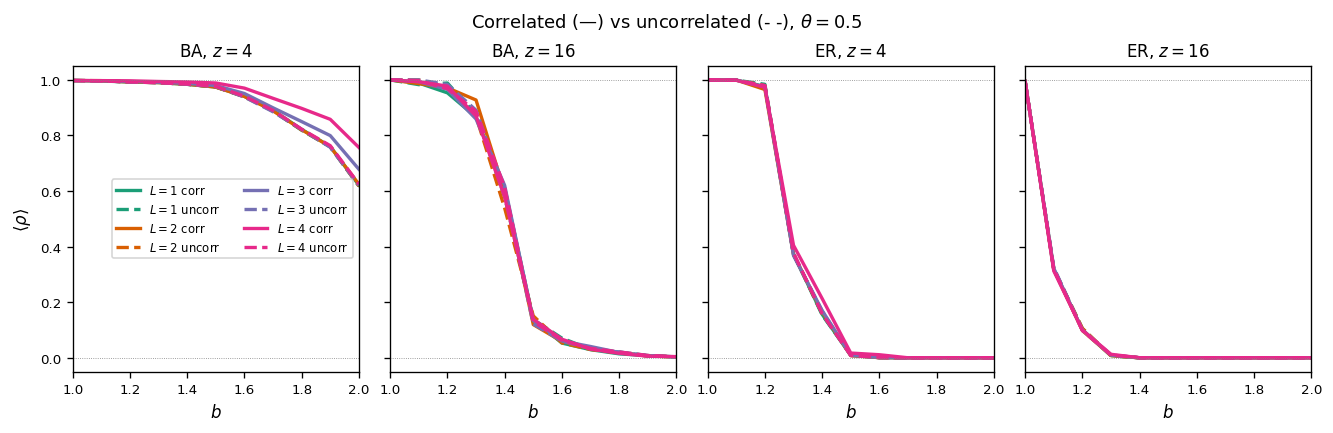

Saved figures/03-marginals-corr-uncorr.pdf


In [9]:
# ── Figure 3: marginals — correlated vs uncorrelated at each L ───────────────
# Solid = correlated, dashed = uncorrelated; colour = L (Dark2).
TH_PLOT = 0.5

fig3, axes3 = plt.subplots(1, len(NETWORKS), figsize=(11, 3.5),
                            constrained_layout=True, sharey=True)

for col, (key, topo, z, label) in enumerate(NETWORKS):
    ax = axes3[col]
    for L in L_VALUES:
        for src, ls, data_dict in [('corr', '-', data_cor), ('uncorr', '--', data_unc)]:
            df  = data_dict[(key, L)]
            sub = df[np.isclose(df['theta'], TH_PLOT)].sort_values('b')
            lbl = f'$L={L}$ {src}' if col == 0 else None
            ax.plot(sub['b'], sub['rho_mean'], ls,
                    color=DARK2[L], lw=LW, label=lbl)
    ax.set_title(label); ax.set_xlabel('$b$')
    if col == 0:
        ax.set_ylabel(r'$\langle\rho\rangle$')
        ax.legend(fontsize=7, ncol=2)
    ax.set_xlim(1.0, 2.0); ax.set_ylim(-0.05, 1.05)
    ax.axhline(0, color='grey', lw=0.5, ls=':')
    ax.axhline(1, color='grey', lw=0.5, ls=':')

fig3.suptitle(f'Correlated (—) vs uncorrelated (- -), $\\theta={TH_PLOT}$')
fig3.savefig('figures/03-marginals-corr-uncorr.pdf', bbox_inches='tight')
plt.show()
print('Saved figures/03-marginals-corr-uncorr.pdf')

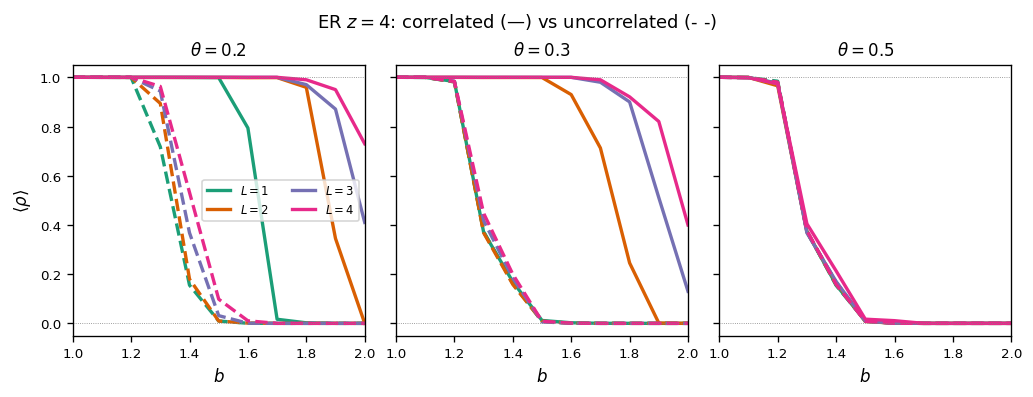

Saved figures/03-marginals-ER4.pdf


In [10]:
# -- Fig. 5 of the main text: ER z=4 only, correlated vs uncorrelated at three theta --
THETA_MAIN = [0.2, 0.3, 0.5]
key_er4 = 'ER_z4'

fig3b, axes3b = plt.subplots(1, len(THETA_MAIN), figsize=(8.5, 3.2),
                              constrained_layout=True, sharey=True)

for col, th in enumerate(THETA_MAIN):
    ax = axes3b[col]
    for L in L_VALUES:
        for src, ls, data_dict in [('corr', '-', data_cor), ('uncorr', '--', data_unc)]:
            df  = data_dict[(key_er4, L)]
            sub = df[np.isclose(df['theta'], th)].sort_values('b')
            lbl = f'$L={L}$' if (col == 0 and src == 'corr') else None
            ax.plot(sub['b'], sub['rho_mean'], ls,
                    color=DARK2[L], lw=LW, label=lbl)
    ax.set_title(f'$\\theta={th}$')
    ax.set_xlabel('$b$')
    if col == 0:
        ax.set_ylabel(r'$\langle\rho\rangle$')
        ax.legend(fontsize=7, ncol=2)
    ax.set_xlim(1.0, 2.0)
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(0, color='grey', lw=0.5, ls=':')
    ax.axhline(1, color='grey', lw=0.5, ls=':')

fig3b.suptitle('ER $z=4$: correlated (—) vs uncorrelated (- -)')
fig3b.savefig('figures/03-marginals-ER4.pdf', bbox_inches='tight')
plt.show()
print('Saved figures/03-marginals-ER4.pdf')

---
## Part III — Robustness: continuity of the correlated-to-uncorrelated transition
*Referee 1, major comment 4. Loads the CSV produced by
`robustness_checks/rewiring_interpolation.py` (run separately, see that script's
docstring) — no simulation is re-run here, only the analysis and figure.*

In [ ]:
# -- Referee 1 major comment 4: is the correlated -> uncorrelated transition
# continuous or discontinuous in the rewired fraction r? Reads the CSV produced
# by robustness_checks/rewiring_interpolation.py (ER z=4, theta=0.2,
# b in {1.3,...,2.0}, r in {0,0.1,...,1.0}, L in {2,4}, 100 replications/point).
# No simulation is (re-)run in this cell.

rw = pd.read_csv("robustness_checks/data/rewiring_interpolation.csv")

B_COLORS_RW = {1.3: "#7f7f7f", 1.5: "#1f77b4", 1.7: "#2ca02c", 1.9: "#ff7f0e", 2.0: "#d62728"}


def crossing_r(r, rho, level):
    """First r (linear interp) where rho crosses `level` going downward."""
    for i in range(len(r) - 1):
        if rho[i] >= level >= rho[i + 1] and rho[i] != rho[i + 1]:
            frac = (rho[i] - level) / (rho[i] - rho[i + 1])
            return r[i] + frac * (r[i + 1] - r[i])
    return np.nan


rows = []
for L in [2, 4]:
    for b in sorted(rw.b.unique()):
        sub = rw[(rw.L == L) & (rw.b == b)].sort_values("r")
        r_ = sub.r.values
        rho_ = sub.rho_mean.values
        std_ = sub.rho_std.values
        r90 = crossing_r(r_, rho_, 0.9)
        r10 = crossing_r(r_, rho_, 0.1)
        width = r10 - r90 if (not np.isnan(r90) and not np.isnan(r10)) else np.nan
        rows.append(dict(L=L, b=b, r_at_rho0p9=r90, r_at_rho0p1=r10,
                          width=width, max_std=std_.max(), r_at_max_std=r_[std_.argmax()]))
table_rw = pd.DataFrame(rows)
print(table_rw.round(3).to_string(index=False))

fig_rw, axes_rw = plt.subplots(2, 2, figsize=(9, 7), sharex=True, constrained_layout=True)
for col, L in enumerate([2, 4]):
    sub = rw[rw.L == L]
    ax_rho, ax_std = axes_rw[0, col], axes_rw[1, col]
    for b in sorted(sub.b.unique()):
        s = sub[sub.b == b].sort_values("r")
        ax_rho.plot(s.r, s.rho_mean, "o-", color=B_COLORS_RW[b], label=f"$b={b}$", ms=4)
        ax_std.plot(s.r, s.rho_std, "o-", color=B_COLORS_RW[b], ms=4)
    ax_rho.set_title(f"$L={L}$")
    ax_rho.set_ylim(-0.03, 1.03)
    ax_std.set_ylim(-0.02, 0.55)
    ax_std.set_xlabel("Rewired fraction $r$")
    if col == 0:
        ax_rho.set_ylabel(r"$\langle\rho\rangle$")
        ax_std.set_ylabel(r"std($\rho$) across replications")
axes_rw[0, 1].legend(loc="upper right", fontsize=8, framealpha=0.9)
fig_rw.suptitle(r"Correlated ($r=0$) $\to$ uncorrelated ($r=1$) interpolation, ER $z=4$, $\theta=0.2$")
fig_rw.savefig("figures/rewiring_interpolation.pdf", bbox_inches="tight")
plt.show()
print("Saved figures/rewiring_interpolation.pdf")


---
## Part IV — Disentangling edge overlap from degree correlation in BA
*Referee 2, comment 6 follow-up. Loads the CSV produced by
`robustness_checks/label_shuffle_control.py` (run separately, see that script's
docstring) — no simulation is re-run here, only the analysis and figure.*

In [ ]:
# -- Referee 2 comment 6 follow-up: does destroying the residual inter-layer
# degree correlation r_k (by permuting G_vig's node labels, on top of the
# existing uncorrelated condition) further reduce BA's residual sensitivity
# to decorrelation? Reads the CSV produced by
# robustness_checks/label_shuffle_control.py (BA z in {4,16}, up to 4
# representative points each, L in {1,4}, 100 replications/point/condition).
# No simulation is (re-)run in this cell.

ls = pd.read_csv("robustness_checks/data/label_shuffle_control.csv")
ls["sem"] = ls["rho_std"] / 10.0  # 100 replications

COND_COLORS_LS = {"corr": "#1f77b4", "uncorr": "#2ca02c", "uncorr_shuffled": "#d62728"}
COND_MARKERS_LS = {"corr": "o", "uncorr": "s", "uncorr_shuffled": "^"}
COND_LABELS_LS = {"corr": "correlated", "uncorr": "uncorrelated",
                   "uncorr_shuffled": "uncorrelated,\nlabel-shuffled"}
DEGENERATE_LS = {(16, "coop")}  # b=1.0, theta=0.0: frozen at the initial state

rows = []
for (z, regime, L), g in ls.groupby(["z", "regime", "L"]):
    g = g.set_index("condition")
    row = dict(z=z, regime=regime, L=L,
               rho_corr=g.loc["corr", "rho_mean"],
               rho_uncorr=g.loc["uncorr", "rho_mean"],
               rho_shuffled=g.loc["uncorr_shuffled", "rho_mean"],
               corr_to_uncorr=g.loc["uncorr", "rho_mean"] - g.loc["corr", "rho_mean"],
               uncorr_to_shuffled=g.loc["uncorr_shuffled", "rho_mean"] - g.loc["uncorr", "rho_mean"],
               sem_uncorr=g.loc["uncorr", "sem"], sem_shuffled=g.loc["uncorr_shuffled", "sem"],
               degenerate=(z, regime) in DEGENERATE_LS)
    rows.append(row)
table_ls = pd.DataFrame(rows).sort_values(["z", "L", "regime"])
table_ls["combined_sem"] = np.sqrt(table_ls.sem_uncorr**2 + table_ls.sem_shuffled**2)
table_ls["z_score"] = table_ls.uncorr_to_shuffled / table_ls.combined_sem
print(table_ls.round(3).to_string(index=False))

informative_ls = table_ls[~table_ls.degenerate & (table_ls.corr_to_uncorr.abs() > 0.02)]
same_dir_ls = (informative_ls.corr_to_uncorr * informative_ls.uncorr_to_shuffled) > 0
print(f"\nInformative points: {len(informative_ls)}; same-direction: {same_dir_ls.sum()}")

fig_ls, axes_ls = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True, sharey=True)
for ax, z in zip(axes_ls, [4, 16]):
    sub = table_ls[table_ls.z == z].reset_index(drop=True)
    xlabels = [f"{r}\nL={L}" + ("*" if deg else "")
               for r, L, deg in zip(sub.regime, sub.L, sub.degenerate)]
    x = np.arange(len(sub))
    for cond, col in [("rho_corr", "corr"), ("rho_uncorr", "uncorr"),
                       ("rho_shuffled", "uncorr_shuffled")]:
        yerr = sub["sem_uncorr"] if col == "uncorr" else (
            sub["sem_shuffled"] if col == "uncorr_shuffled" else None)
        ax.errorbar(x, sub[cond], yerr=yerr, fmt=COND_MARKERS_LS[col], color=COND_COLORS_LS[col],
                    label=COND_LABELS_LS[col], ms=7, capsize=3, lw=1)
    for xi in x:
        ax.plot([xi, xi, xi], [sub.rho_corr[xi], sub.rho_uncorr[xi], sub.rho_shuffled[xi]],
                color="grey", lw=0.7, zorder=0, alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, fontsize=8)
    ax.set_title(f"BA $z={z}$")
    ax.set_ylim(-0.05, 1.05)
    if z == 4:
        ax.set_ylabel(r"$\langle\rho\rangle$")
axes_ls[1].legend(loc="upper right", fontsize=8, framealpha=0.9)
fig_ls.suptitle("Correlated vs. uncorrelated vs. label-shuffled BA multiplex "
                 "(* = degenerate point, see text)")
fig_ls.savefig("figures/label_shuffle_control.pdf", bbox_inches="tight")
plt.show()
print("Saved figures/label_shuffle_control.pdf")
